# **Data Understanding**


The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

## **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## **Data Explore**

In [2]:
df = pd.read_csv('creditcard.csv')
df.shape
df.head(20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.duplicated().sum()

np.int64(1081)

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## **Exploratory Data Analysis (EDA)**

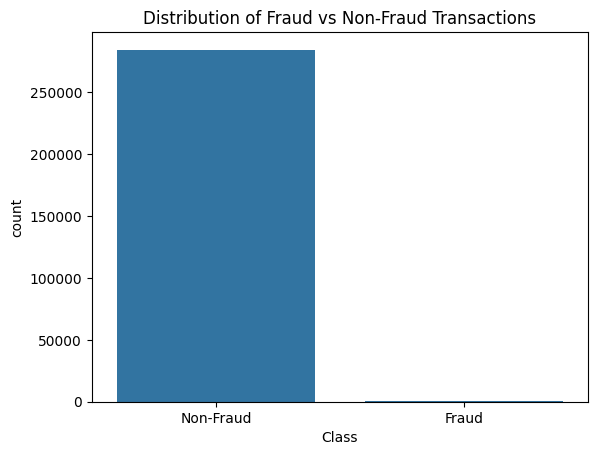

In [8]:
#Class Distribution
sns.countplot(x='Class',data=df)
plt.title("Distribution of Fraud vs Non-Fraud Transactions")
plt.xticks([0, 1], ['Non-Fraud','Fraud'])
plt.show()

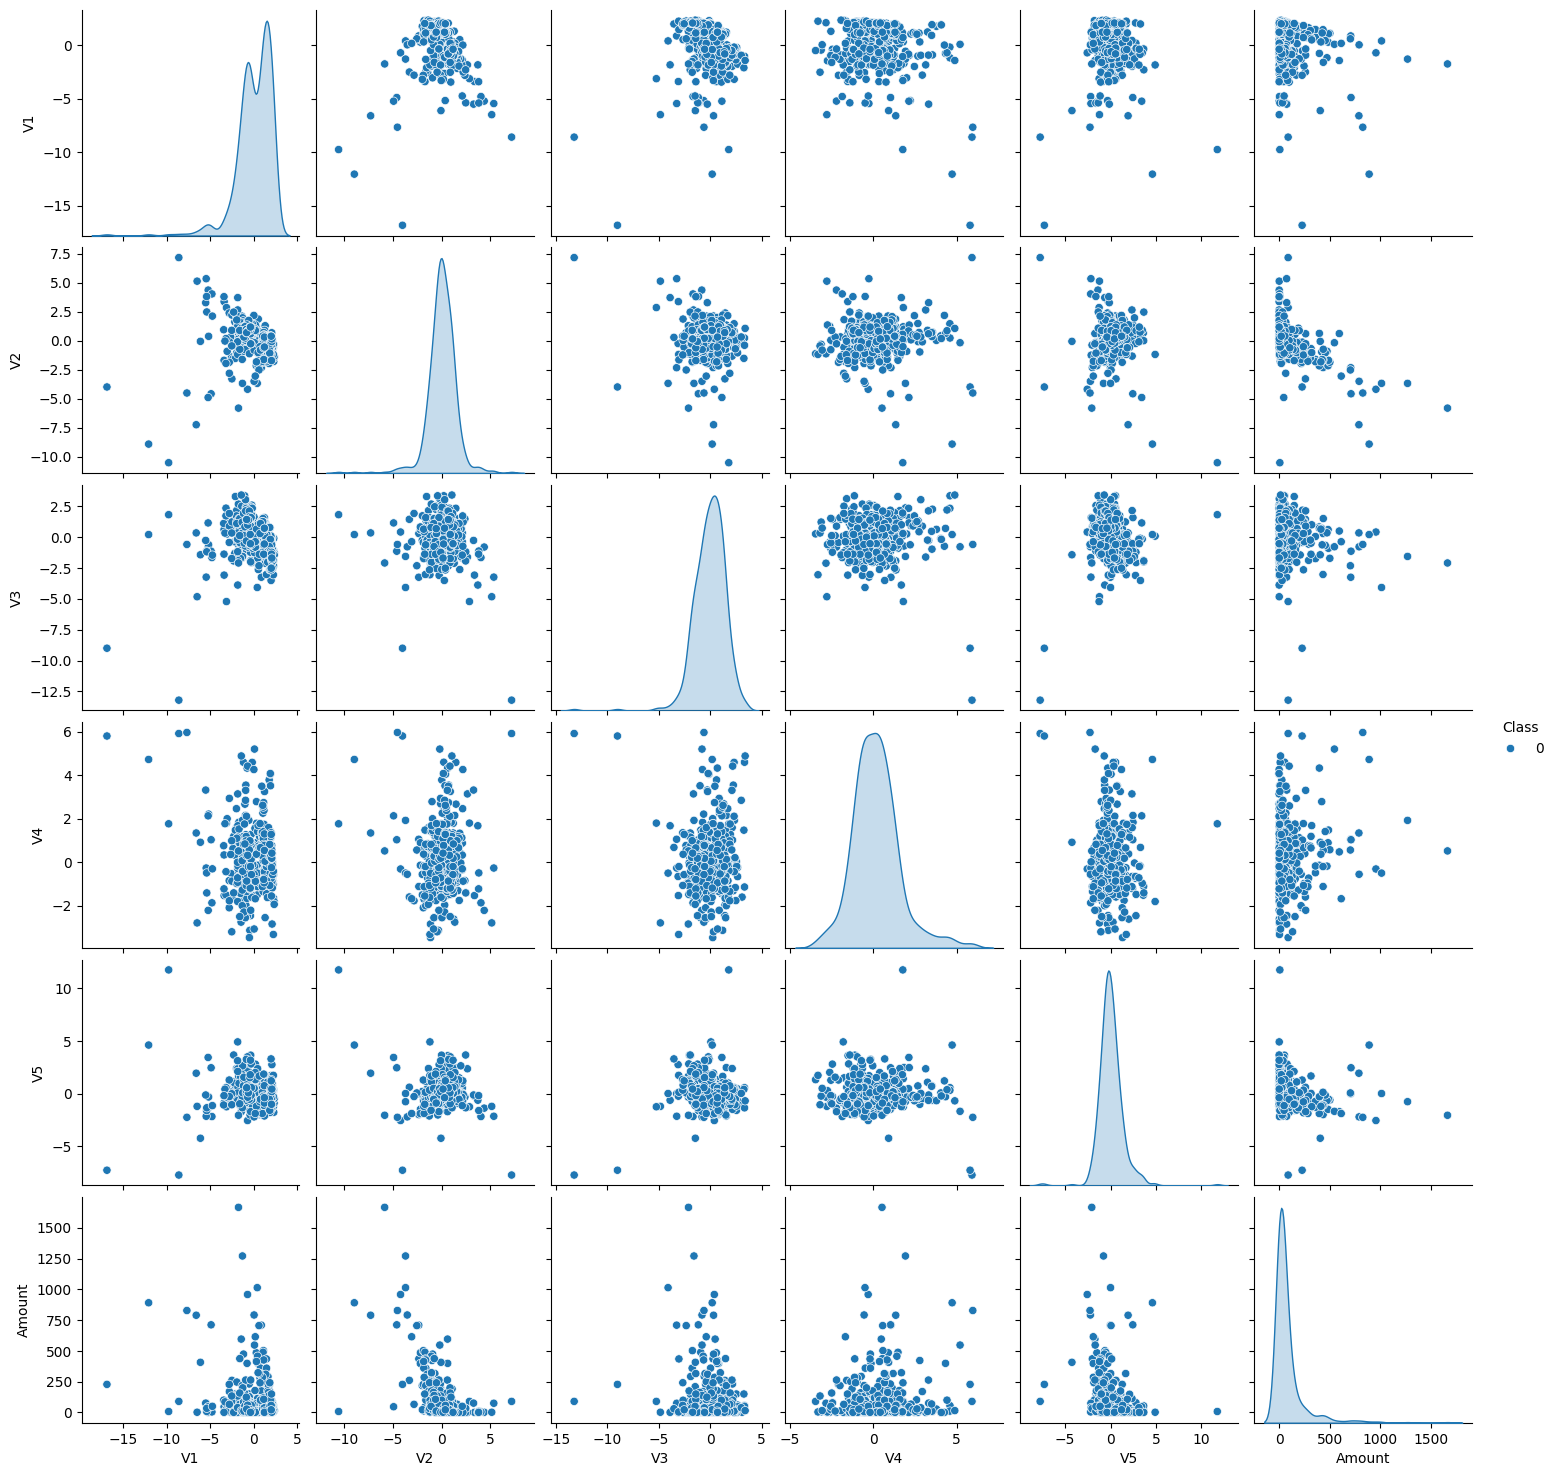

In [ ]:
#Pairplot
temp_df = df.sample(500)
temp_df['Class'] = temp_df['Class'].astype(str)
sns.pairplot(temp_df[['V1','V2','V3','V4','V5','Amount','Class']],hue='Class')
plt.show()

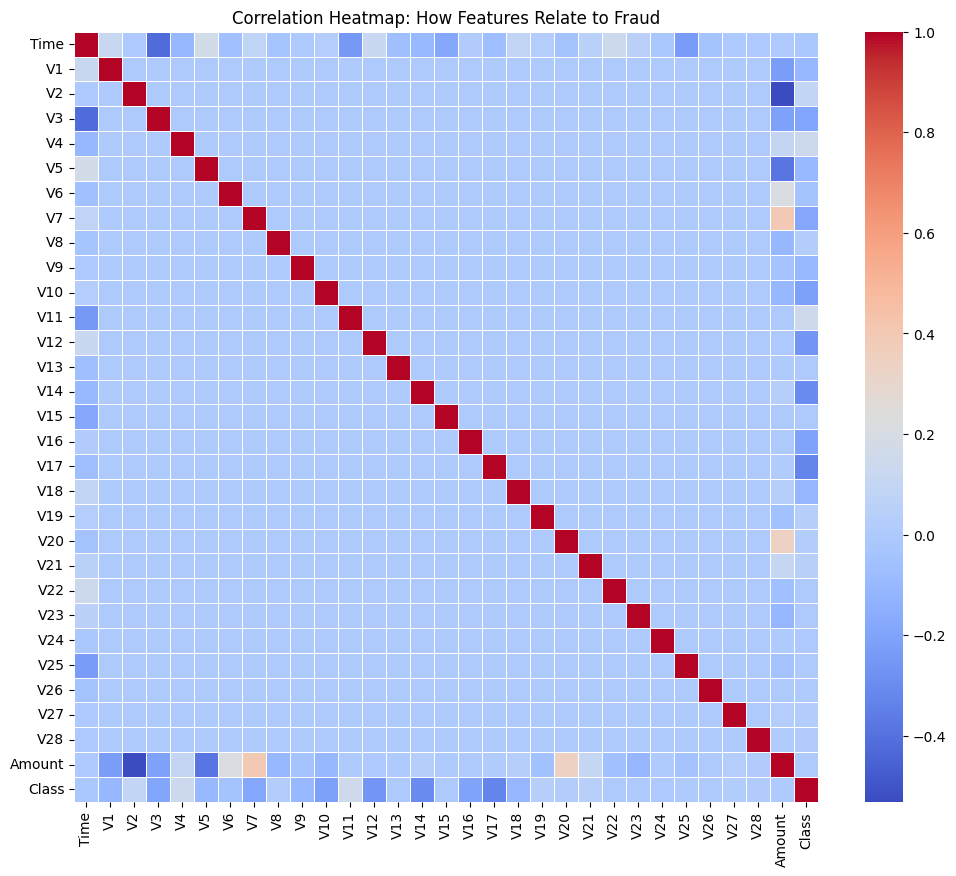

In [ ]:
#Correlation heatmap
plt.figure(figsize=(12, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=False,cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Heatmap: How Features Relate to Fraud")
plt.show()

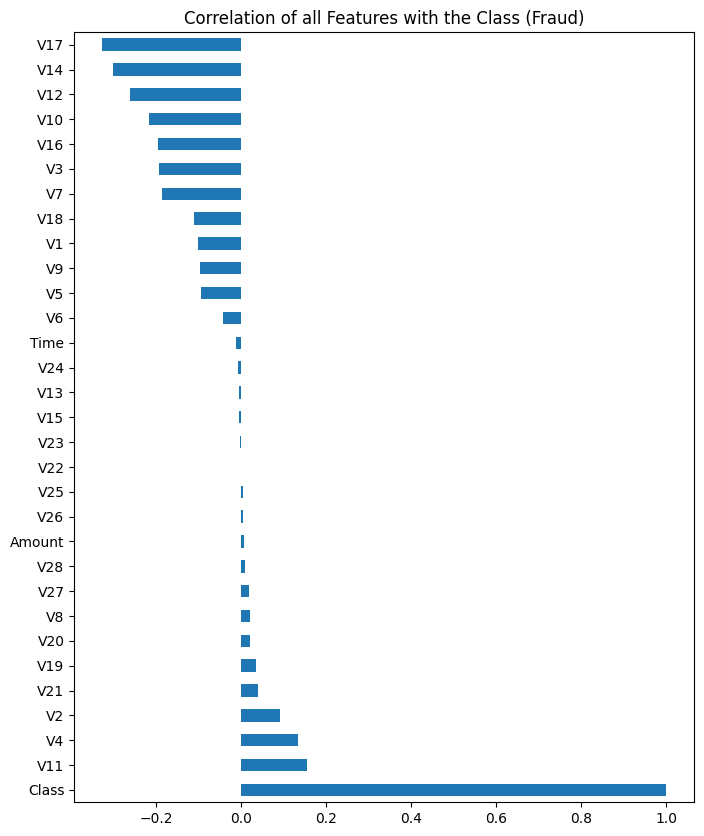

In [ ]:
#Feature Correlation with Class
plt.figure(figsize=(8,10))
df.corr()['Class'].sort_values(ascending=False).plot(kind='barh')
plt.title("Correlation of all Features with the Class (Fraud)")
plt.show()

## **Data Handling & Preprocessing**

In [12]:
#Drop Duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:
#Drop Time Column
df_cleaned = df.drop(columns=['Time'])
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print("Remaining columns:",df_cleaned.columns.tolist())

Original shape: (283726, 31)
Cleaned shape: (283726, 30)
Remaining columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [ ]:
#Split Features and Target
X = df_cleaned.drop('Class',axis=1)
y = df_cleaned['Class']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (226980, 29) | X_test: (56746, 29)


In [15]:
#Scale Amount
scaler = RobustScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount']  = scaler.transform(X_test[['Amount']])

In [ ]:
#Undersampling
rus = RandomUnderSampler(random_state=42)
X_under,y_under = rus.fit_resample(X_train,y_train)
print("After Undersampling")
print(pd.Series(y_under).value_counts())

After Undersampling
Class
0    378
1    378
Name: count, dtype: int64


In [ ]:
#Oversampling (SMOTE)
sm = SMOTE(random_state=42)
X_over,y_over = sm.fit_resample(X_train,y_train)
print("After SMOTE")
print(pd.Series(y_over).value_counts())

After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64


In [18]:
#SMOTEENN
smoteenn = SMOTEENN(random_state=42)
X_combined,y_combined = smoteenn.fit_resample(X_train,y_train)
print("After SMOTEENN")
print(pd.Series(y_combined).value_counts())

After SMOTEENN
Class
1    226602
0    226244
Name: count, dtype: int64


In [19]:
#Sampling Sets
sampling_sets = {
    "Undersampling" : (X_under,y_under),
    "SMOTE"         : (X_over,y_over),
    "SMOTEENN"      : (X_combined,y_combined),
}

# **Logistic Regression**

In [ ]:
#Train and Evaluate
lr = LogisticRegression(max_iter=1000, random_state=42)

for sampling_name, (X_res, y_res) in sampling_sets.items():
    lr.fit(X_res,y_res)
    y_pred = lr.predict(X_test)
    print(f"Logistic Regression - {sampling_name}")
    print(classification_report(y_test,y_pred,target_names=['Non-Fraud','Fraud']))

  Logistic Regression - Undersampling
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.09        95

    accuracy                           0.97     56746
   macro avg       0.52      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746

  Logistic Regression - SMOTE
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

  Logistic Regression - SMOTEENN
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53    

# **Decision Tree**

In [ ]:
#Train and Evaluate
dt = DecisionTreeClassifier(random_state=42)

for sampling_name,(X_res,y_res) in sampling_sets.items():
    dt.fit(X_res,y_res)
    y_pred = dt.predict(X_test)
    print(f"Decision Tree - {sampling_name}")
    print(classification_report(y_test,y_pred,target_names=['Non-Fraud','Fraud']))

  Decision Tree - Undersampling
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.92      0.96     56651
       Fraud       0.02      0.92      0.04        95

    accuracy                           0.92     56746
   macro avg       0.51      0.92      0.50     56746
weighted avg       1.00      0.92      0.96     56746

  Decision Tree - SMOTE
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.35      0.67      0.46        95

    accuracy                           1.00     56746
   macro avg       0.68      0.84      0.73     56746
weighted avg       1.00      1.00      1.00     56746

  Decision Tree - SMOTEENN
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.36      0.73      0.48        95

    accuracy                           1.00     56746
   macro avg       0.68      0.86      0.74  

# **Random Forest**

In [ ]:
#Train and Evaluate
rf = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)

for sampling_name,(X_res,y_res) in sampling_sets.items():
    rf.fit(X_res,y_res)
    y_pred = rf.predict(X_test)
    print(f"Random Forest - {sampling_name}")
    print(classification_report(y_test,y_pred,target_names=['Non-Fraud','Fraud']))

  Random Forest - Undersampling
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.98      0.99     56651
       Fraud       0.08      0.86      0.15        95

    accuracy                           0.98     56746
   macro avg       0.54      0.92      0.57     56746
weighted avg       1.00      0.98      0.99     56746

  Random Forest - SMOTE
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

  Random Forest - SMOTEENN
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.87      0.80      0.84        95

    accuracy                           1.00     56746
   macro avg       0.94      0.90      0.92  

# **XGBoost**

In [ ]:
#Train and Evaluate
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)

for sampling_name,(X_res, y_res) in sampling_sets.items():
    xgb.fit(X_res,y_res)
    y_pred = xgb.predict(X_test)
    print(f"XGBoost - {sampling_name}")
    print(classification_report(y_test,y_pred,target_names=['Non-Fraud','Fraud']))

  XGBoost - Undersampling
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.97      0.99     56651
       Fraud       0.05      0.86      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746

  XGBoost - SMOTE
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.75      0.78      0.76        95

    accuracy                           1.00     56746
   macro avg       0.87      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746

  XGBoost - SMOTEENN
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.72      0.81      0.76        95

    accuracy                           1.00     56746
   macro avg       0.86      0.90      0.88     56746
weighted 

# **Confusion Matrices**

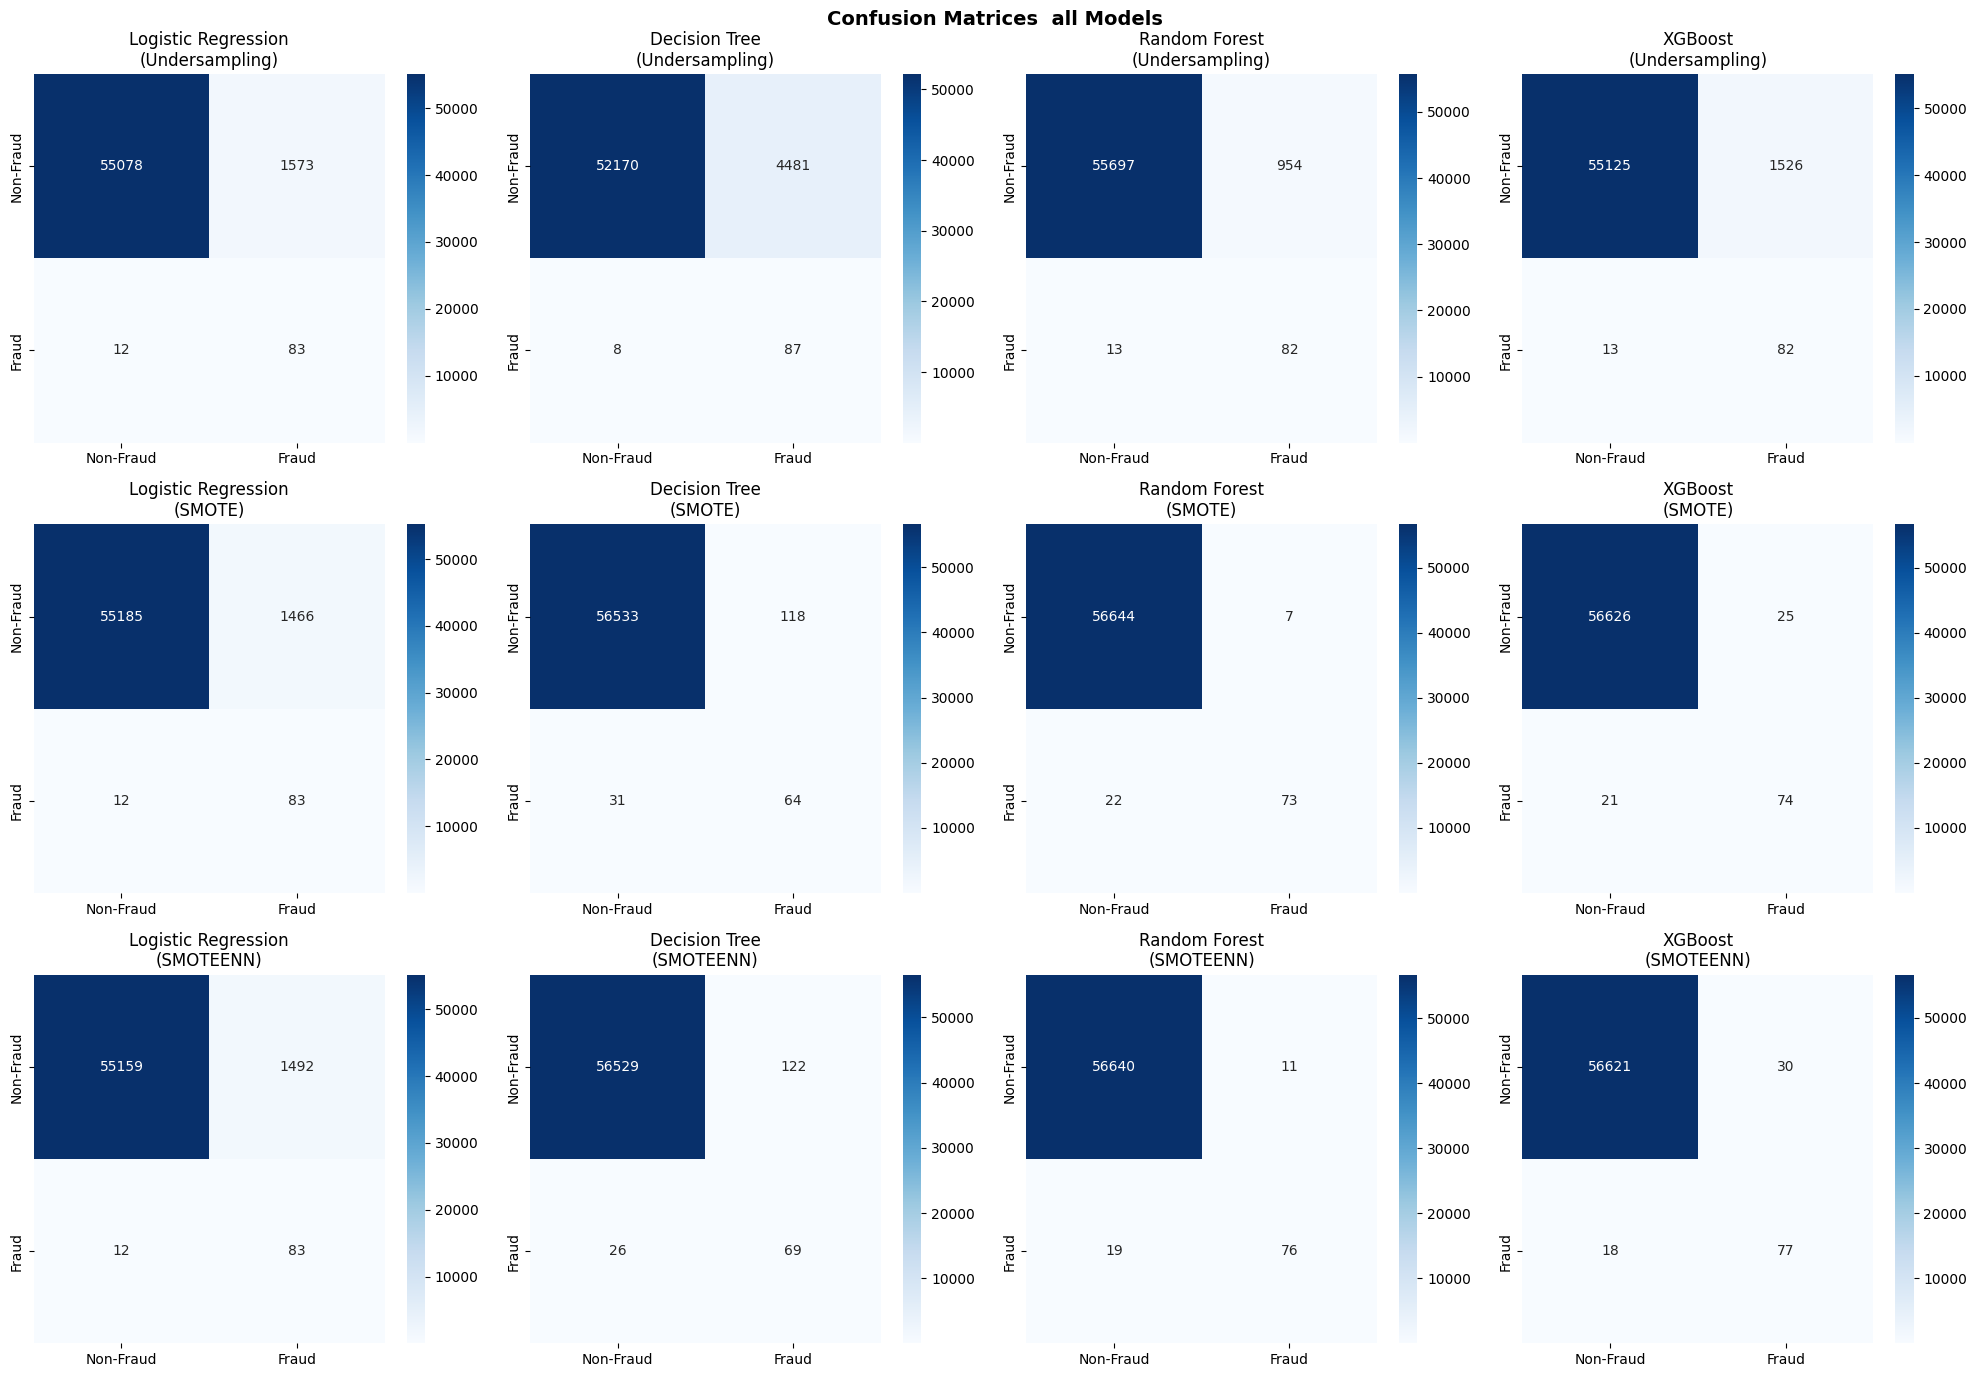

In [ ]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
}

fig, axes = plt.subplots(3,4,figsize=(20,14))

for row_idx,(sampling_name,(X_res, y_res)) in enumerate(sampling_sets.items()):
    for col_idx,(name, model) in enumerate(models.items()):
        model.fit(X_res,y_res)
        cm = confusion_matrix(y_test,model.predict(X_test))
        sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[row_idx][col_idx],xticklabels=['Non-Fraud','Fraud'],yticklabels=['Non-Fraud','Fraud'])
        axes[row_idx][col_idx].set_title(f"{name}\n({sampling_name})")

plt.suptitle("Confusion Matrices  all Models",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

# **ROC-AUC**

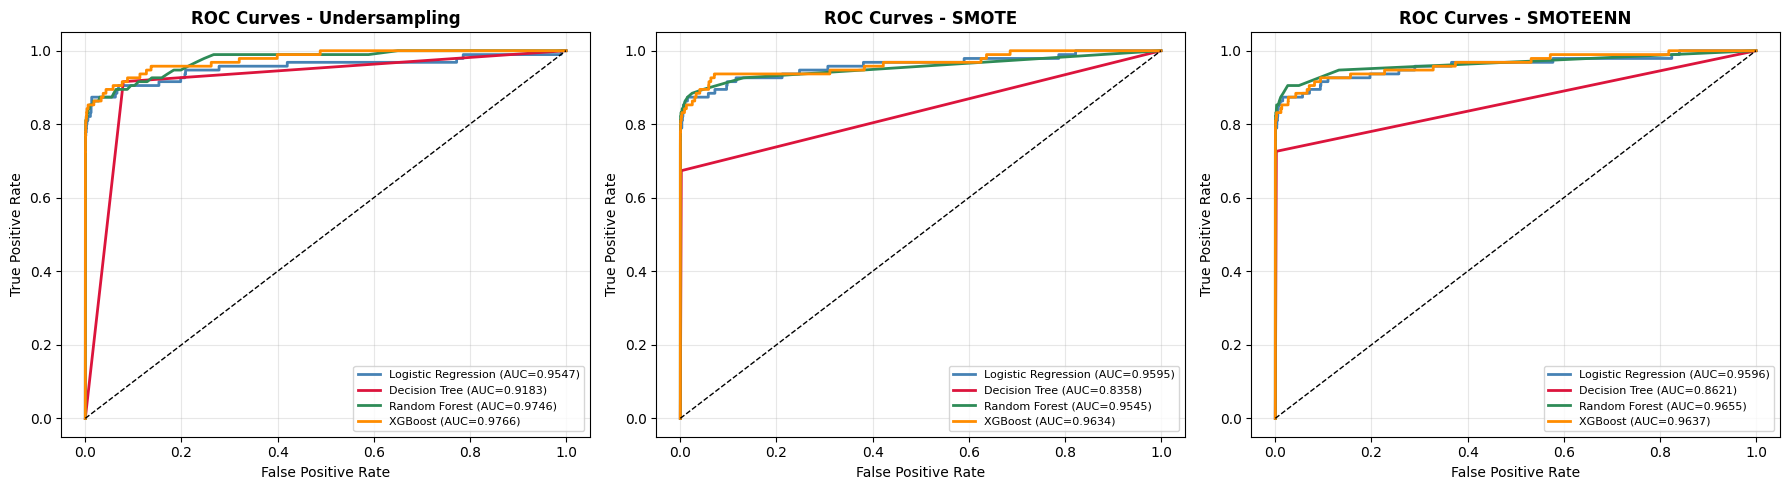

In [ ]:
#ROC-AUC Curves
colors = ['steelblue','crimson','seagreen','darkorange']
fig,axes = plt.subplots(1,3,figsize=(18,5))

for ax, (sampling_name, (X_res,y_res)) in zip(axes,sampling_sets.items()):
    for color,(name,model) in zip(colors,models.items()):
        model.fit(X_res,y_res)
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test,y_prob)
        auc = roc_auc_score(y_test,y_prob)
        ax.plot(fpr,tpr,color=color,lw=2,label=f"{name} (AUC={auc:.4f})")
    ax.plot([0, 1], [0, 1],'k--',lw=1)
    ax.set_title(f"ROC Curves - {sampling_name}", fontweight='bold')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **Model Comparison**

In [ ]:
results = []

for sampling_name,(X_res,y_res) in sampling_sets.items():
    for model_name,model in models.items():
        model.fit(X_res,y_res)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        results.append({
            "Sampling"  : sampling_name,
            "Model"     : model_name,
            "Precision" : round(precision_score(y_test, y_pred),4),
            "Recall"    : round(recall_score(y_test, y_pred),4),
            "F1-Score"  : round(f1_score(y_test, y_pred),4),
            "AUC-ROC"   : round(roc_auc_score(y_test, y_prob),4),
        })

results_df = pd.DataFrame(results).sort_values("F1-Score",ascending=False).reset_index(drop=True)
results_df

,Sampling,Model,Precision,Recall,F1-Score,AUC-ROC
0,SMOTEENN,Random Forest,0.8736,0.8000,0.8352,0.9655
1,SMOTE,Random Forest,0.9125,0.7684,0.8343,0.9545
2,SMOTE,XGBoost,0.7475,0.7789,0.7629,0.9634
3,SMOTEENN,XGBoost,0.7196,0.8105,0.7624,0.9637
4,SMOTEENN,Decision Tree,0.3613,0.7263,0.4825,0.8621
5,SMOTE,Decision Tree,0.3516,0.6737,0.4621,0.8358
6,Undersampling,Random Forest,0.0792,0.8632,0.1450,0.9746
7,SMOTE,Logistic Regression,0.0536,0.8737,0.1010,0.9595
8,SMOTEENN,Logistic Regression,0.0527,0.8737,0.0994,0.9596
9,Undersampling,XGBoost,0.0510,0.8632,0.0963,0.9766


# **Conclusion**

In [27]:
best = results_df.iloc[0]
print("PROJECT CONCLUSION")
print(f"\nBest Model: {best['Model']}")
print(f"Sampling: {best['Sampling']}")
print(f"Precision: {best['Precision']}")
print(f"Recall: {best['Recall']}")
print(f"F1-Score: {best['F1-Score']}")
print(f"AUC-ROC: {best['AUC-ROC']}")
print(
    """
Key Findings:
    Accuracy is misleading for imbalanced data, used F1 and AUC-ROC instead
    SMOTE and SMOTEENN outperform Undersampling in most cases
    XGBoost and Random Forest achieve the highest AUC-ROC
    Logistic Regression is a solid baseline after SMOTE
    Decision Tree is interpretable but weaker than ensemble models

Future Improvements:
    Hyperparameter tuning with GridSearchCV
    Threshold tuning for better Precision/Recall trade-off
    Cost-sensitive learning with class_weight= balanced
    """
)

PROJECT CONCLUSION

Best Model: Random Forest
Sampling: SMOTEENN
Precision: 0.8736
Recall: 0.8
F1-Score: 0.8352
AUC-ROC: 0.9655

Key Findings:
    Accuracy is misleading for imbalanced data, used F1 and AUC-ROC instead
    SMOTE and SMOTEENN outperform Undersampling in most cases
    XGBoost and Random Forest achieve the highest AUC-ROC
    Logistic Regression is a solid baseline after SMOTE
    Decision Tree is interpretable but weaker than ensemble models

Future Improvements:
    Hyperparameter tuning with GridSearchCV
    Threshold tuning for better Precision/Recall trade-off
    Cost-sensitive learning with class_weight= balanced
    
